## Importing Libraries

In [1]:
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import librosa.display

# Configure GPU memory growth BEFORE importing TensorFlow models
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ Memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError:
        # Runtime already initialized - that's okay on re-runs
        pass

from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.image import resize
import json

import soundfile as sf
import scipy.io.wavfile as wav_reader

def load_wav_file(path):
    # Method 1: soundfile (fastest, handles most WAVs)
    try:
        audio_data, sample_rate = sf.read(path, dtype='float32', always_2d=False)
        if audio_data.ndim > 1:          # stereo → mono
            audio_data = audio_data.mean(axis=1)
        return audio_data, sample_rate

    except Exception:
        pass

    # Method 2: scipy (handles edge-case WAV encodings on Windows)
    try:
        sample_rate, audio_data = wav_reader.read(path)
        audio_data = audio_data.astype(np.float32)
        if audio_data.ndim > 1:          # stereo → mono
            audio_data = audio_data.mean(axis=1)
        # Normalize int16/int32 PCM to [-1.0, 1.0]
        if audio_data.max() > 1.0:
            audio_data /= np.iinfo(np.int16).max
        return audio_data, sample_rate

    except Exception:
        pass

    # Method 3: librosa last resort
    audio_data, sample_rate = librosa.load(path, sr=None, mono=True)
    return audio_data, sample_rate

✓ Memory growth enabled for 1 GPU(s)


## Visualizing Single Audio

(661794,)

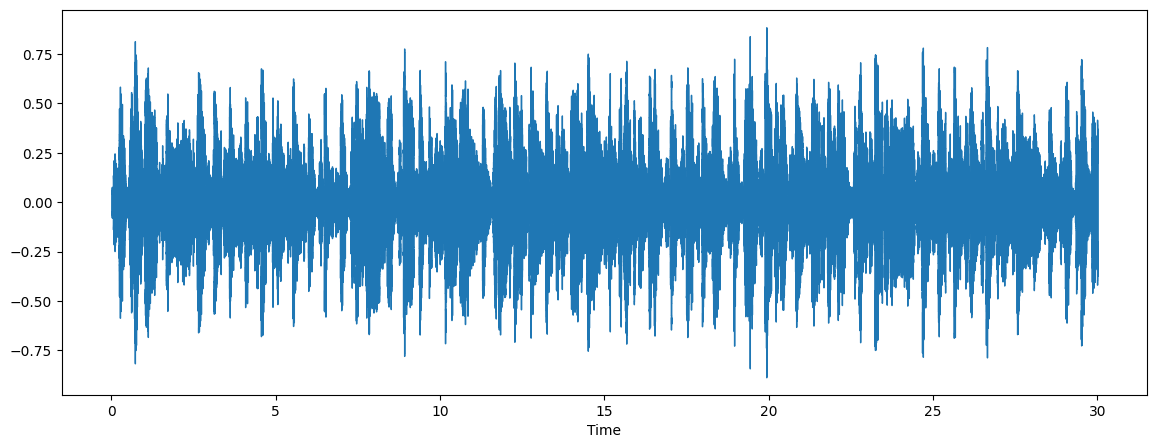

In [2]:
random_file_name = "blues.00000.wav"
y, sr = load_wav_file(random_file_name)
plt.figure(figsize=(14, 5))
librosa.display.waveshow(y, sr=sr)
y.shape


## Playing Sound

In [3]:
from IPython.display import Audio
Audio(data=y, rate=sr)

### Doing Visualization on chunks of Audio

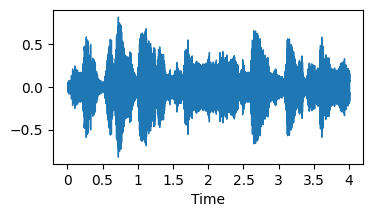

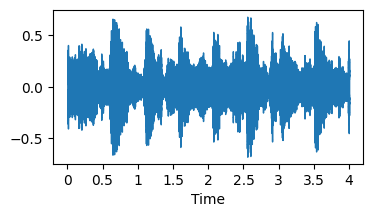

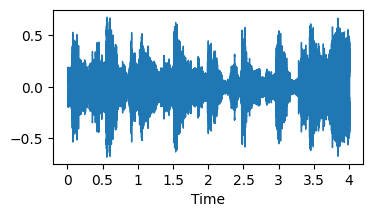

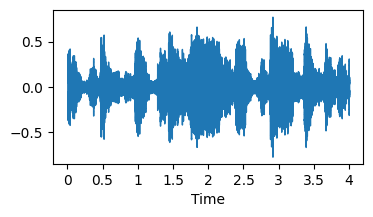

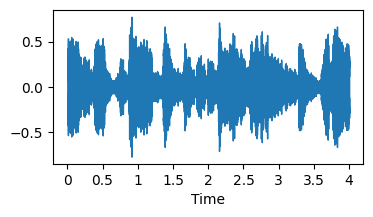

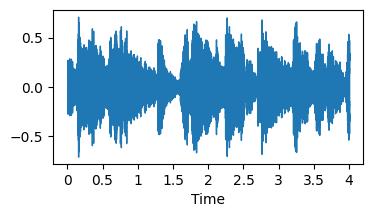

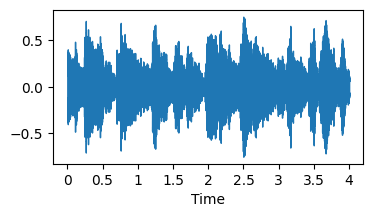

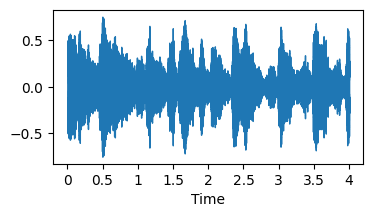

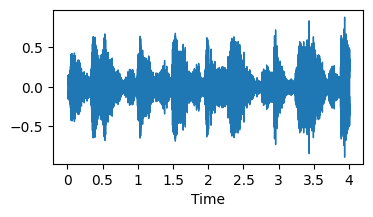

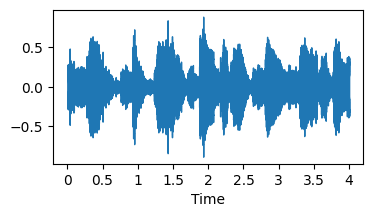

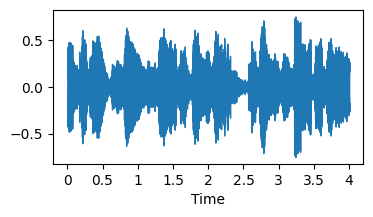

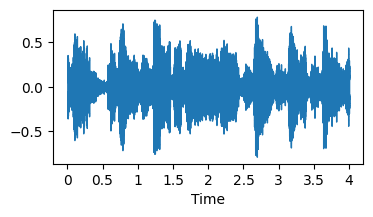

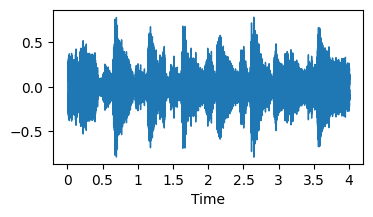

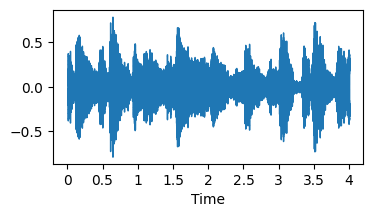

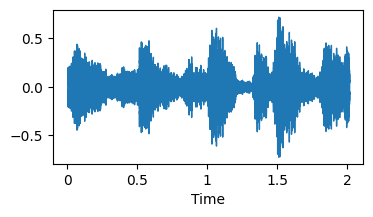

In [4]:
### Doing Visualization on chunks of Audio
audio_path = "./blues.00000.wav"
y, sr = load_wav_file(audio_path)

chunk_duration = 4
overlap_duration = 2

# FIX 2: Wrap in int() to prevent float index TypeError
chunk_samples  = int(chunk_duration  * sr)
overlap_samples = int(overlap_duration * sr)

num_chunks = int(np.ceil((len(y) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

for i in range(num_chunks):
    start = int(i * (chunk_samples - overlap_samples))   # FIX 2
    end   = int(start + chunk_samples)                    # FIX 2
    chunk = y[start:end]
    plt.figure(figsize=(4, 2))
    librosa.display.waveshow(chunk, sr=sr)
    plt.show()


## Melspectrogram Visualization

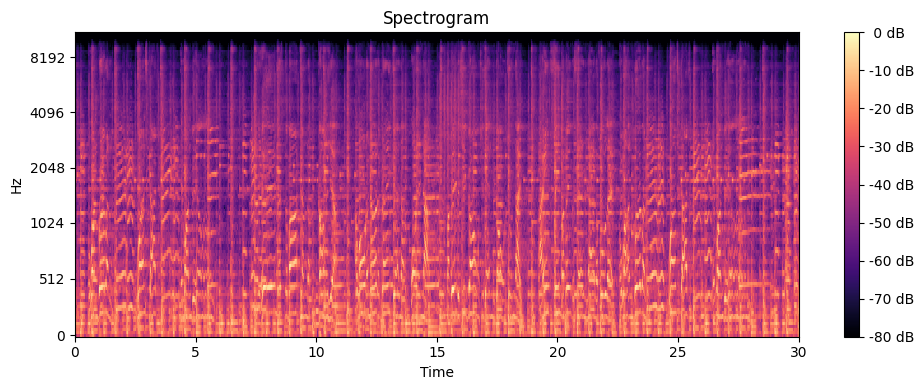

(128, 173)


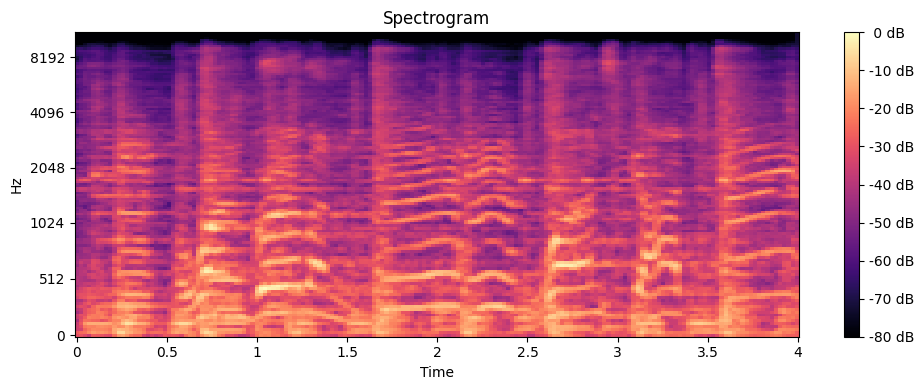

(128, 173)


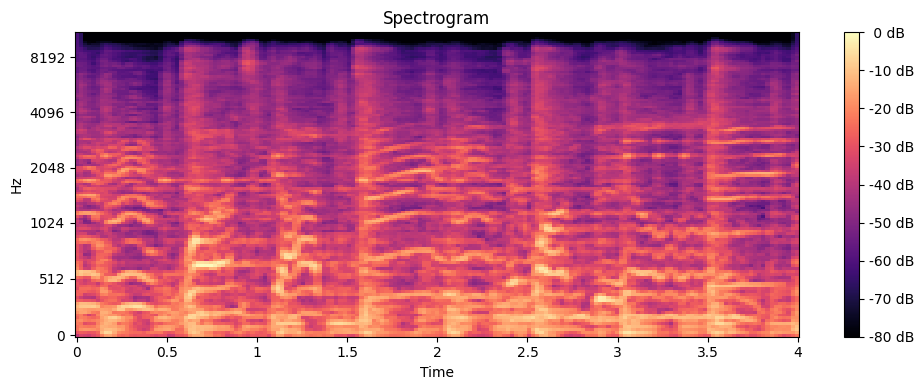

(128, 173)


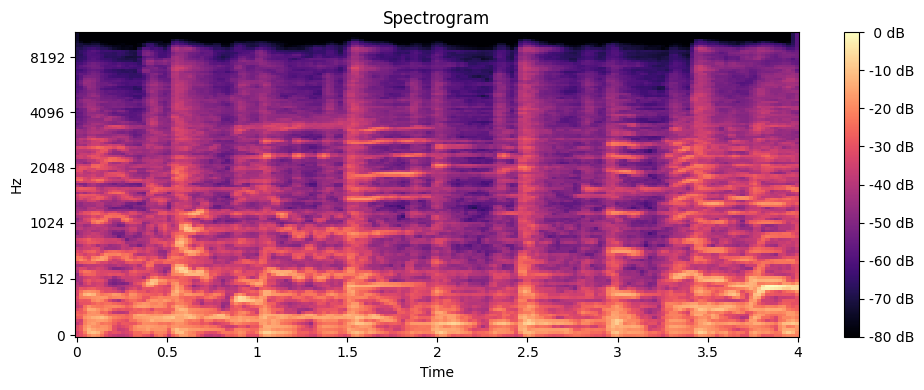

(128, 173)


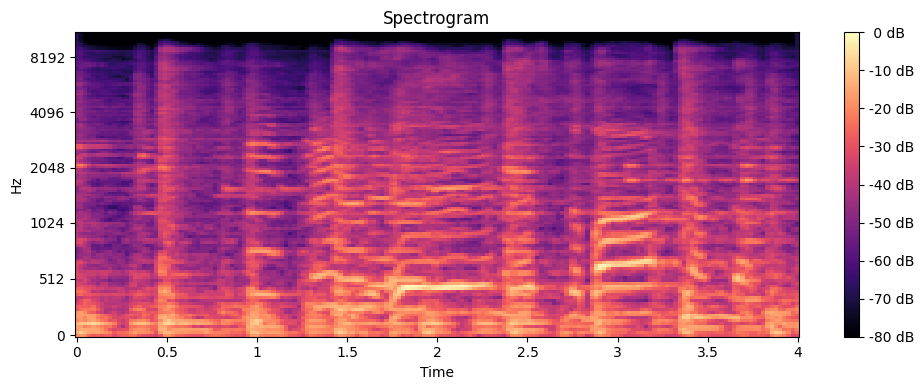

(128, 173)


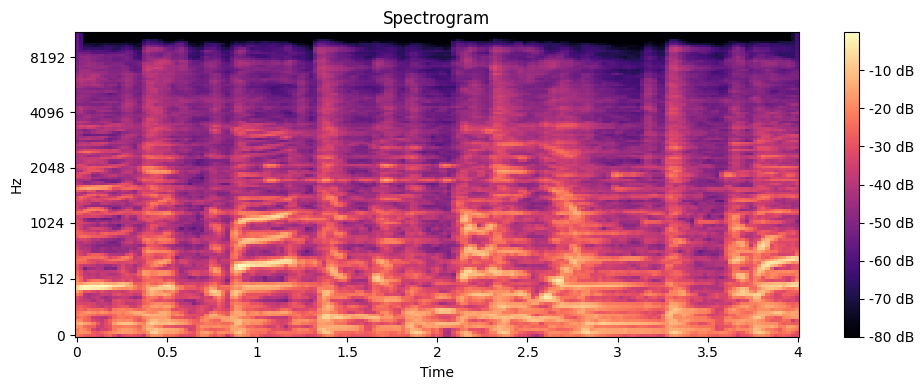

(128, 173)


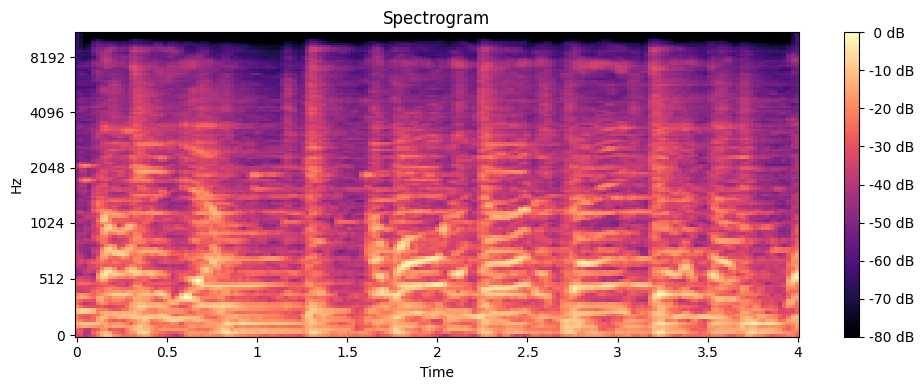

(128, 173)


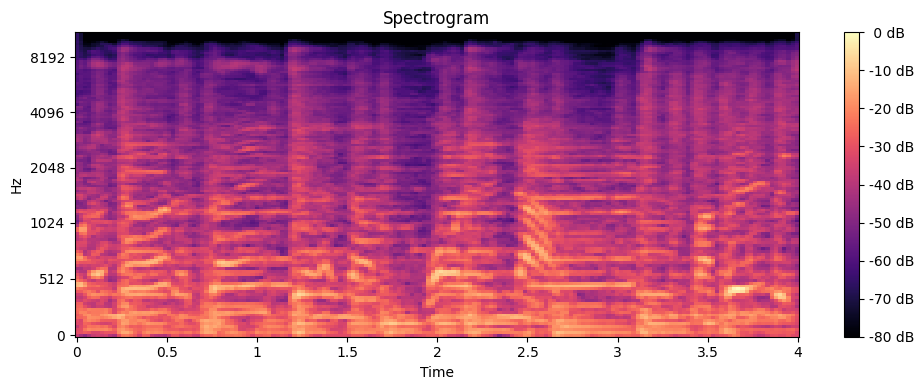

(128, 173)


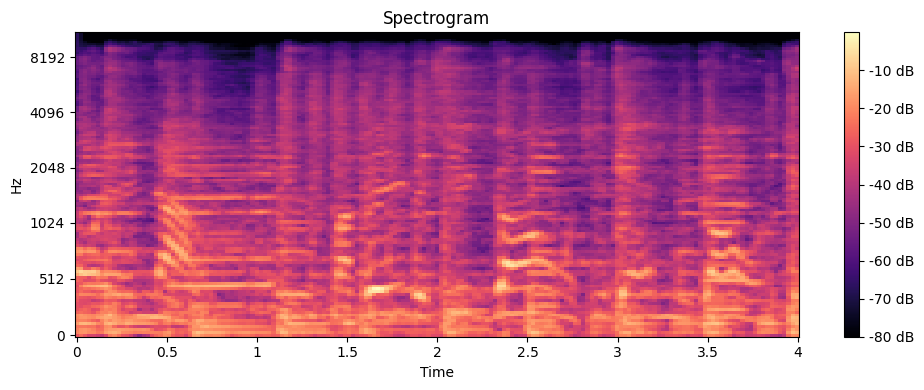

(128, 173)


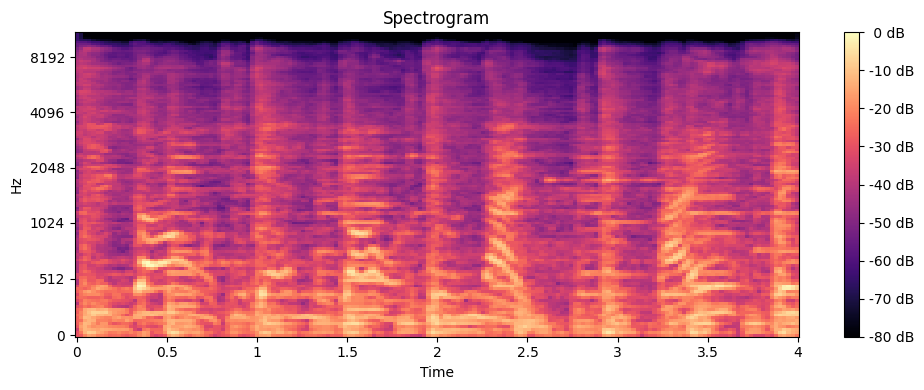

(128, 173)


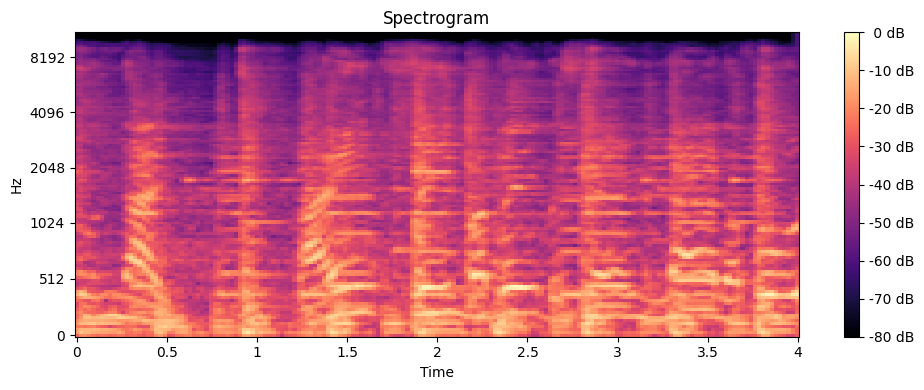

(128, 173)


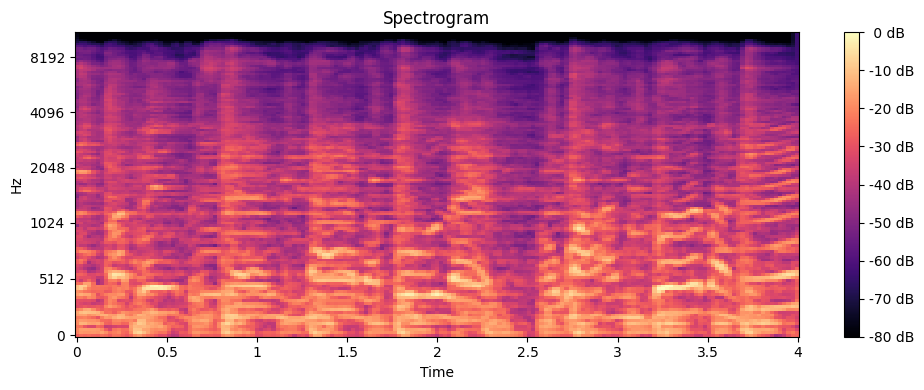

(128, 173)


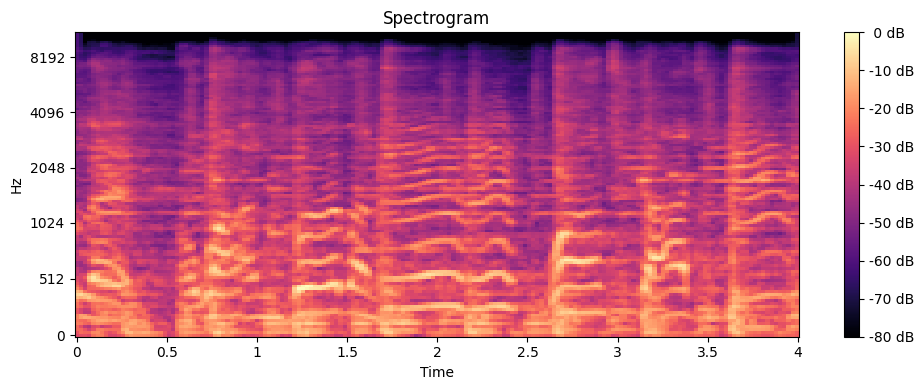

(128, 173)


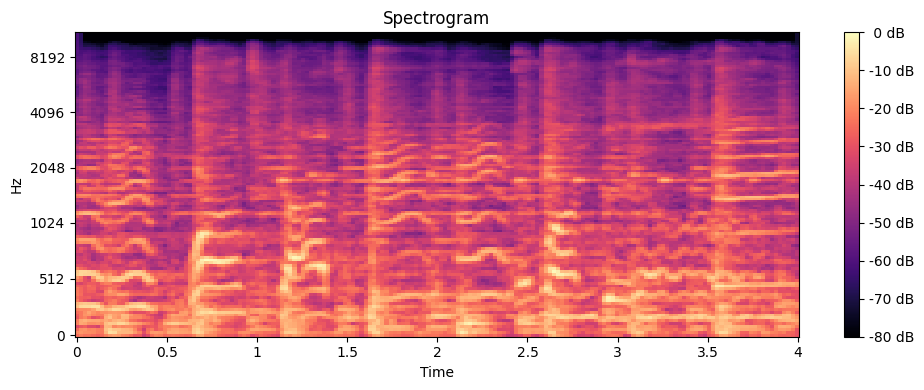

(128, 173)


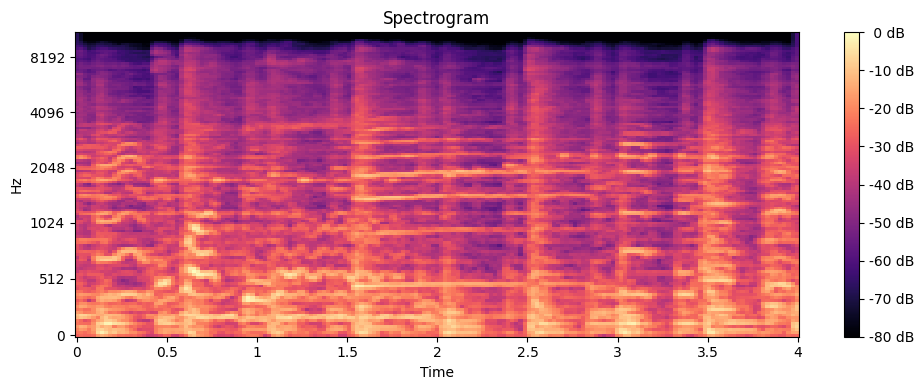

(128, 87)


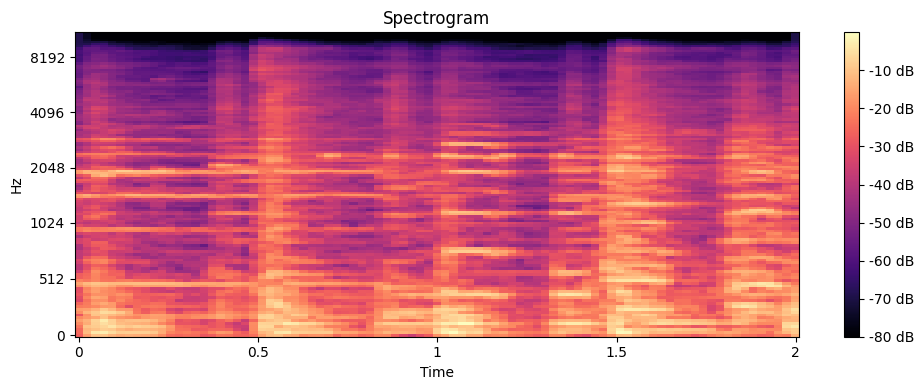

In [5]:
def plot_melspectrogram(y, sr):
    spectrogram = librosa.feature.melspectrogram(y=y, sr=sr)
    spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

    plt.figure(figsize=(10, 4))
    librosa.display.specshow(
        spectrogram_db,
        sr=sr,
        x_axis='time',
        y_axis='mel'
    )
    plt.colorbar(format='%2.0f dB')
    plt.title("Spectrogram")
    plt.tight_layout()
    plt.show()


# =========================================================
# CHUNKED MEL SPECTROGRAM
# =========================================================
def plot_melspectrogram_chunks(y, sr):

    # define duration
    chunk_duration = 4
    overlap_duration = 2

    # convert to samples
    chunk_samples = int(chunk_duration * sr)
    overlap_samples = int(overlap_duration * sr)

    step = chunk_samples - overlap_samples

    # number of chunks
    num_chunks = int(np.ceil((len(y) - chunk_samples) / step)) + 1

    # iterate chunks
    for i in range(num_chunks):

        start = int(i * step)
        end = int(start + chunk_samples)

        chunk = y[start:end]

        # compute mel spectrogram
        spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sr)
        print(spectrogram.shape)

        spectrogram_db = librosa.power_to_db(spectrogram, ref=np.max)

        # plot
        plt.figure(figsize=(10, 4))
        librosa.display.specshow(
            spectrogram_db,
            sr=sr,
            x_axis='time',
            y_axis='mel'
        )
        plt.colorbar(format='%2.0f dB')
        plt.title("Spectrogram")
        plt.tight_layout()
        plt.show()


# =========================================================
# RUN EXAMPLE
# =========================================================
random_file_name = "./blues.00000.wav"
y, sr = load_wav_file(random_file_name)

plot_melspectrogram(y, sr)
plot_melspectrogram_chunks(y, sr)

## Data Preprocessing - Final

In [6]:
data_dir = "./genres_original"
classes  = ['blues','classical','country','disco','hiphop','jazz','metal','pop','reggae','rock']

def load_and_preprocess_data(data_dir, classes, target_shape=(150, 150)):
    data   = []
    labels = []

    for i_class, class_name in enumerate(classes):
        class_dir = os.path.join(data_dir, class_name)
        print("Processing --", class_name)
        for filename in os.listdir(class_dir):
            if filename.endswith('.wav'):
                file_path = os.path.join(class_dir, filename)

                # ── safely load the file, skip if all backends fail ──
                try:
                    audio_data, sample_rate = load_wav_file(file_path)
                except Exception as e:
                    print(f"  Skipping {filename}: {e}")
                    continue

                chunk_duration   = 4
                overlap_duration = 2
                chunk_samples    = int(chunk_duration  * sample_rate)
                overlap_samples  = int(overlap_duration * sample_rate)
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) /
                                        (chunk_samples - overlap_samples))) + 1

                for i in range(num_chunks):
                    start = int(i * (chunk_samples - overlap_samples))
                    end   = int(start + chunk_samples)
                    chunk = audio_data[start:end]

                    mel_spectrogram = librosa.feature.melspectrogram(y=chunk, sr=sample_rate)
                    mel_spectrogram = resize(
                        np.expand_dims(mel_spectrogram.astype(np.float32), axis=-1),
                        target_shape
                    )
                    data.append(mel_spectrogram)
                    labels.append(i_class)

    return np.array(data), np.array(labels)

data, labels = load_and_preprocess_data(data_dir, classes)
print(data.shape, labels.shape)

from tensorflow.keras.utils import to_categorical
labels = to_categorical(labels, num_classes=len(classes))

from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

Processing -- blues
Processing -- classical
Processing -- country
Processing -- disco
Processing -- hiphop
Processing -- jazz
Processing -- metal
Processing -- pop
Processing -- reggae
Processing -- rock
(2996, 150, 150, 1) (2996,)


# Building Model

In [7]:
model = tf.keras.models.Sequential()

In [8]:
X_train[0].shape

(150, 150, 1)

In [9]:
model.add(Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=X_train[0].shape))
model.add(Conv2D(filters=32,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [10]:
model.add(Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=64,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [11]:
model.add(Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=128,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [12]:
model.add(Dropout(0.3))

In [13]:
model.add(Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=256,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [14]:
model.add(Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
model.add(Conv2D(filters=512,kernel_size=3,activation='relu'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [15]:
model.add(Dropout(0.3))

In [16]:
model.add(Flatten())

In [17]:
model.add(Dense(units=1200,activation='relu'))

In [18]:
model.add(Dropout(0.45))

In [19]:
#Output layer
model.add(Dense(units=len(classes),activation='softmax'))

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                    

In [21]:
#Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [22]:
#Training Model
training_history = model.fit(X_train,Y_train,epochs=30,batch_size=32,validation_data=(X_test,Y_test))

Epoch 1/30
75/75 [==============================] - 39s 310ms/step - loss: 2.1959 - accuracy: 0.1511 - val_loss: 2.1035 - val_accuracy: 0.2217
Epoch 2/30
75/75 [==============================] - 15s 195ms/step - loss: 2.0520 - accuracy: 0.2533 - val_loss: 1.9547 - val_accuracy: 0.3817
Epoch 3/30
75/75 [==============================] - 16s 209ms/step - loss: 1.7956 - accuracy: 0.3631 - val_loss: 1.5361 - val_accuracy: 0.4667
Epoch 4/30
75/75 [==============================] - 15s 206ms/step - loss: 1.5403 - accuracy: 0.4541 - val_loss: 1.3300 - val_accuracy: 0.5417
Epoch 5/30
75/75 [==============================] - 15s 204ms/step - loss: 1.3049 - accuracy: 0.5442 - val_loss: 1.2360 - val_accuracy: 0.5867
Epoch 6/30
75/75 [==============================] - 15s 203ms/step - loss: 1.0941 - accuracy: 0.6198 - val_loss: 1.0621 - val_accuracy: 0.6467
Epoch 7/30
75/75 [==============================] - 15s 201ms/step - loss: 1.0139 - accuracy: 0.6436 - val_loss: 0.9307 - val_accuracy: 0.6733

In [23]:
model.save("Trained_model.keras") #Mac
model.save("Trained_model.h5") #Windows

In [24]:
training_history.history

{'loss': [2.195929527282715,
  2.0520222187042236,
  1.7955515384674072,
  1.5402594804763794,
  1.304868221282959,
  1.0941053628921509,
  1.0139139890670776,
  0.893916130065918,
  0.7866561412811279,
  0.6955806612968445,
  0.6128843426704407,
  0.5532813668251038,
  0.513910174369812,
  0.4669189453125,
  0.4108048677444458,
  0.338527113199234,
  0.3016775846481323,
  0.2799712121486664,
  0.28173089027404785,
  0.23934590816497803,
  0.24365432560443878,
  0.22239206731319427,
  0.15071509778499603,
  0.1808255910873413,
  0.12638859450817108,
  0.10246735066175461,
  0.0840558409690857,
  0.07833478599786758,
  0.08957391232252121,
  0.23644760251045227],
 'accuracy': [0.15108513832092285,
  0.25333890318870544,
  0.3631051778793335,
  0.4540901482105255,
  0.544240415096283,
  0.6197829842567444,
  0.6435726284980774,
  0.6848914623260498,
  0.7220367193222046,
  0.7616861462593079,
  0.7833889722824097,
  0.8005008101463318,
  0.8259599208831787,
  0.8434891700744629,
  0.8564

In [25]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [26]:
X_train

array([[[[5.37200496e-02],
         [1.38888344e-01],
         [1.34999812e-01],
         ...,
         [2.03034210e+00],
         [1.97834194e+00],
         [1.45604169e+00]],

        [[8.12371552e-01],
         [4.33907938e+00],
         [5.02742910e+00],
         ...,
         [7.09071274e+01],
         [4.99814415e+01],
         [3.04429798e+01]],

        [[1.96981323e+00],
         [5.09431744e+00],
         [4.19827080e+00],
         ...,
         [1.54971680e+02],
         [9.23721695e+01],
         [3.74008980e+01]],

        ...,

        [[1.65845428e-04],
         [3.81644677e-05],
         [3.65666182e-07],
         ...,
         [1.74390564e-08],
         [2.11235347e-05],
         [2.63270398e-04]],

        [[1.50858337e-04],
         [3.10003088e-05],
         [2.72637397e-08],
         ...,
         [7.17208160e-09],
         [2.09848477e-05],
         [2.61596491e-04]],

        [[1.45859100e-04],
         [2.97897168e-05],
         [5.83925086e-09],
         ...,
 

In [27]:
#Reloading model variable
model = tf.keras.models.load_model("Trained_model.h5")
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      320       
                                                                 
 conv2d_1 (Conv2D)           (None, 148, 148, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 74, 74, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 74, 74, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 72, 72, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 36, 36, 64)       0         
 2D)                                                    

In [28]:
#Reloading Training history
import json
with open("training_hist.json",'r') as json_file:
    training_history_data = json.load(json_file)

In [29]:
training_history_data.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [30]:
print(X_train.shape)
print(Y_train.shape)

print(X_train.dtype)
print(Y_train.dtype)

print(tf.config.list_physical_devices('GPU'))

(2396, 150, 150, 1)
(2396, 10)
float32
float32
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Model Evaluation - I

19/19 [==============================] - 1s 54ms/step - loss: 0.5049 - accuracy: 0.8567
Train: 0.9791 | Val: 0.8567


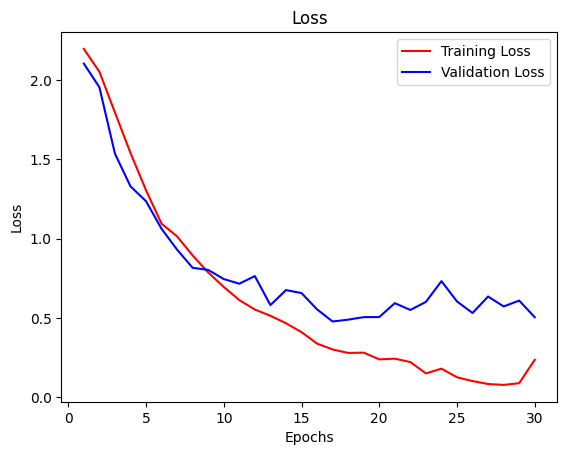

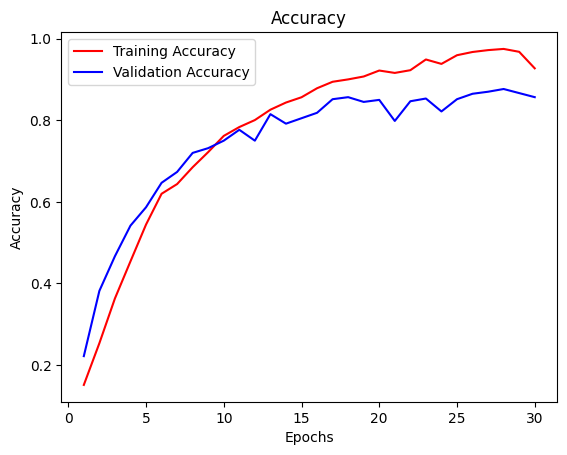

In [31]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
tf.keras.backend.clear_session()

model = tf.keras.models.load_model("Trained_model.keras")

with open("training_hist.json", 'r') as f:
    training_history_data = json.load(f)

# Use batch_size to avoid dumping the full dataset to GPU at once
# Check if data is defined first - use try-except instead of globals()
try:
    train_loss, train_accuracy = model.evaluate(X_train, Y_train, batch_size=32, verbose=1)
    val_loss,   val_accuracy   = model.evaluate(X_test,  Y_test,  batch_size=32, verbose=1)
    print(f"Train: {train_accuracy:.4f} | Val: {val_accuracy:.4f}")
except NameError:
    print("Warning: Training/test data not loaded. Please run data loading cells first.")

# Dynamically get actual epoch count from history instead of hardcoding 30
num_epochs = len(training_history_data['loss'])
epochs = range(1, num_epochs + 1)

plt.plot(epochs, training_history_data['loss'],     label="Training Loss",   color='red')
plt.plot(epochs, training_history_data['val_loss'], label="Validation Loss", color='blue')
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.title("Loss"); plt.legend(); plt.show()

plt.plot(epochs, training_history_data['accuracy'],     label="Training Accuracy",   color='red')
plt.plot(epochs, training_history_data['val_accuracy'], label="Validation Accuracy", color='blue')
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.title("Accuracy"); plt.legend(); plt.show()


# Building Model

In [32]:
train_loss,train_accuracy

(0.07445703446865082, 0.9791318774223328)

In [33]:
#Model evaluation on Validation set
val_loss,val_accuracy = model.evaluate(X_test,Y_test)

19/19 [==============================] - 1s 56ms/step - loss: 0.5049 - accuracy: 0.8567


In [34]:
val_loss,val_accuracy

(0.5048781633377075, 0.8566666841506958)

In [35]:
training_history_data['val_loss']

[2.103496789932251,
 1.9546736478805542,
 1.53612220287323,
 1.329971432685852,
 1.2359769344329834,
 1.062119722366333,
 0.9306885004043579,
 0.8162246942520142,
 0.8031988143920898,
 0.7455324530601501,
 0.7161777019500732,
 0.7642975449562073,
 0.5811415910720825,
 0.6761032342910767,
 0.6572210788726807,
 0.5544810891151428,
 0.4779728651046753,
 0.48975732922554016,
 0.5056114792823792,
 0.5059877038002014,
 0.5937578082084656,
 0.5507091879844666,
 0.6016106605529785,
 0.732508659362793,
 0.604364812374115,
 0.531384289264679,
 0.6355096697807312,
 0.5727830529212952,
 0.6099008917808533,
 0.5048781633377075]

## Accuracy and Loss Visualization

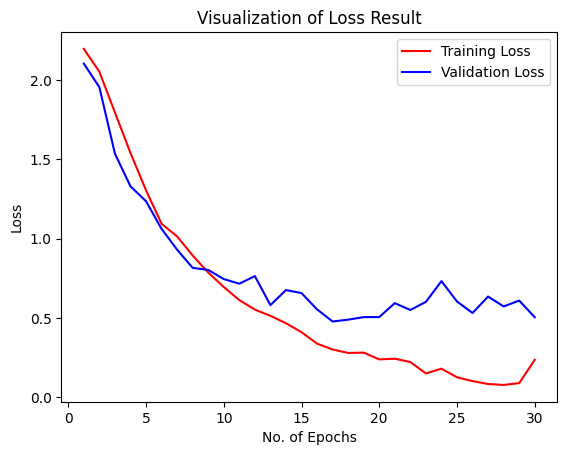

In [36]:
#Visualization of Loss
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['loss'],label="Training Loss",color='red')
plt.plot(epochs,training_history_data['val_loss'],label="Validation Loss",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Loss")
plt.title("Visualization of Loss Result")
plt.legend()
plt.show()

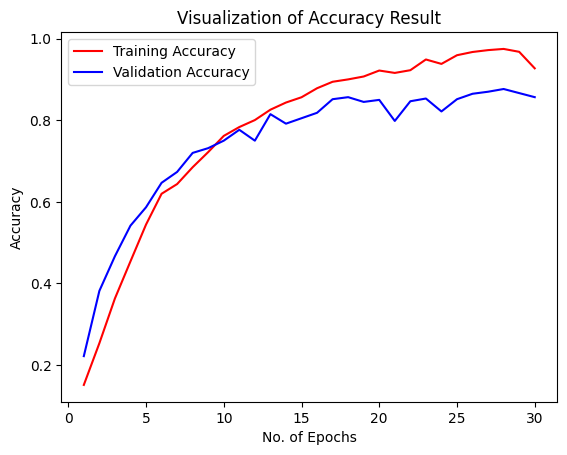

In [37]:
#Visualization of Accuracy
epochs = [i for i in range(1,31)]
plt.plot(epochs,training_history_data['accuracy'],label="Training Accuracy",color='red')
plt.plot(epochs,training_history_data['val_accuracy'],label="Validation Accuracy",color='blue')
plt.xlabel("No. of Epochs")
plt.ylabel("Accuracy")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

## Precision,Recall,Confusion Matrix - Model Evaluation-II

In [38]:
# =========================================================
# MODEL PREDICTION
# =========================================================

print("X_test shape:", X_test.shape)

y_pred = model.predict(X_test)
print("y_pred:", y_pred)
print("y_pred shape:", y_pred.shape)

predicted_categories = np.argmax(y_pred, axis=1)
print("Predicted categories:", predicted_categories)


# =========================================================
# TRUE LABELS
# =========================================================

print("Y_test shape:", Y_test.shape)

true_categories = np.argmax(Y_test, axis=1)
print("True categories:", true_categories)


# =========================================================
# CLASS LABELS
# =========================================================

print("Classes:", classes)


# =========================================================
# EVALUATION METRICS
# =========================================================

from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(true_categories, predicted_categories)

print("\nClassification Report:\n")
print(classification_report(
    true_categories,
    predicted_categories,
    target_names=classes
))

X_test shape: (600, 150, 150, 1)
19/19 [==============================] - 2s 52ms/step
y_pred: [[3.37991878e-05 8.05703593e-09 3.99497112e-05 ... 7.71557493e-03
  5.12638007e-06 2.16386504e-02]
 [4.90825514e-08 1.03326958e-10 9.66673624e-03 ... 5.55574952e-04
  4.74338466e-03 5.21236586e-07]
 [9.79513466e-01 8.88537954e-08 7.27740722e-03 ... 1.25718934e-05
  7.53323693e-05 5.36666112e-03]
 ...
 [9.86560464e-01 1.81673693e-06 1.61753141e-03 ... 9.38083849e-06
  2.23707780e-03 7.58123906e-06]
 [4.80535887e-02 6.18147737e-08 6.92050874e-01 ... 6.32496958e-04
  2.52650142e-01 4.66114783e-04]
 [1.42974997e-04 4.50467587e-06 1.38022490e-02 ... 1.32091194e-01
  1.02400735e-01 2.36722303e-06]]
y_pred shape: (600, 10)
Predicted categories: [4 3 0 2 0 1 7 0 9 8 6 5 3 8 9 9 4 5 6 7 8 2 0 6 7 4 0 8 7 0 5 2 0 8 9 4 9
 3 0 4 1 6 6 2 0 3 0 5 5 5 3 7 3 1 5 9 9 1 1 5 9 1 4 2 2 8 5 6 8 0 5 3 8 4
 1 7 2 2 9 7 1 3 7 7 1 9 6 5 1 5 0 6 0 3 0 9 6 0 8 6 6 5 9 0 0 9 3 9 2 5 6
 3 9 7 3 5 4 5 9 2 9 1 8 8 5 7 9 2

## Confusion Matrix Visualization

In [39]:
cm

array([[63,  0,  3,  1,  0,  1,  1,  2,  2,  0],
       [ 0, 52,  0,  0,  0, 17,  0,  0,  0,  0],
       [ 1,  0, 52,  0,  0,  2,  0,  1,  0,  1],
       [ 0,  0,  0, 55,  1,  0,  0,  3,  0,  1],
       [ 1,  0,  0,  1, 43,  0,  2,  1,  2,  2],
       [ 0,  2,  3,  0,  0, 47,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  0,  0, 56,  0,  0,  0],
       [ 0,  1,  0,  2,  2,  6,  1, 40,  1,  3],
       [ 2,  0,  4,  0,  0,  0,  0,  0, 53,  0],
       [ 0,  0,  2,  1,  0,  0,  2,  7,  1, 53]], dtype=int64)

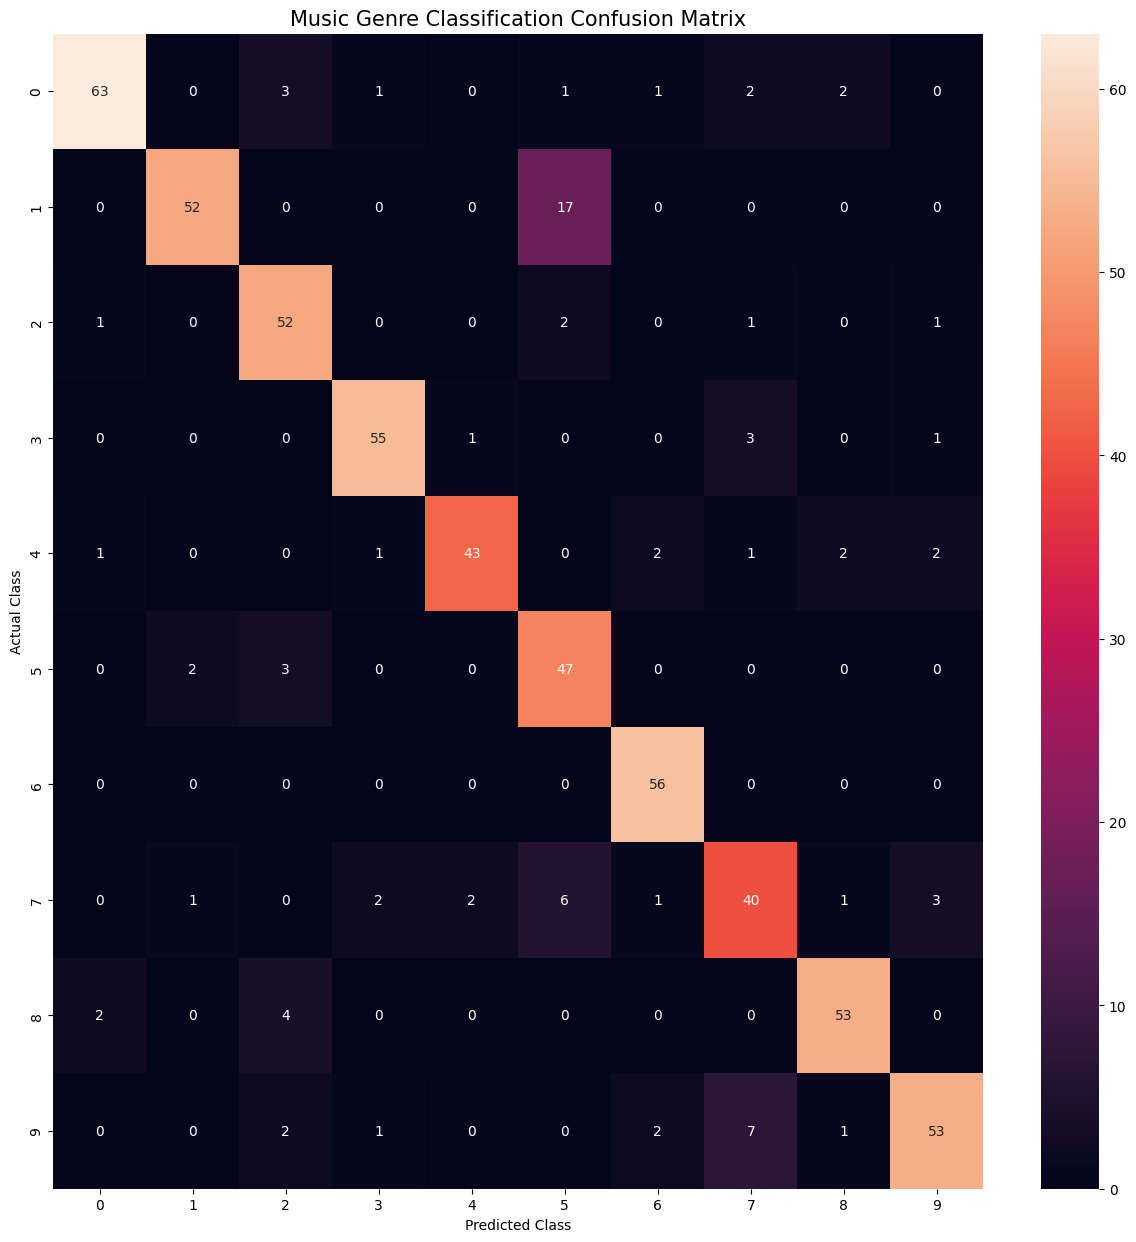

In [40]:
import seaborn as sns
plt.figure(figsize=(15,15))
sns.heatmap(cm,annot=True,annot_kws={"size":10})
plt.xlabel("Predicted Class",fontsize=10)
plt.ylabel("Actual Class",fontsize=10)
plt.title("Music Genre Classification Confusion Matrix",fontsize=15)
plt.show()